<a href="https://colab.research.google.com/github/ZuhaaAsif/Applied-Search-Intelligence-Google-Search-Ranking-Discoverability/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZuhaaAsif/Applied-Search-Intelligence-Google-Search-Ranking-Discoverability/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: Which pages are earning fewer clicks than their search position should predict, and can that gap be ranked well enough to serve as a weekly shortlist for a content reviewer?

Decision supported: which of 100,000+ pages a reviewer with limited time checks first for a title/metadata review. This mirrors the paper's Introduction section directly.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

FlyRank's internship warehouse (Hugging Face, pseudonymized): 104 clients, 519,606 content items, 78,835,655 daily rows, 2025-01-27 to 2026-06-30. This study uses one mid-panel month; March 2026, 9,841,378 rows; deliberately avoiding the sealed final-month holdout. Joined fact_content_daily_performance with dim_content for content type and age. Excluded: FlyRank's own product-decision flags (health score, priority score, action type), never used as features, since they'd let a model learn an existing rule instead of discover anything. GA4/engagement fields excluded from the final model; only 4.2% of March rows had real GA4 coverage, too thin to build on. No client names, URLs, or raw query text anywhere in this notebook.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Unit of analysis: one content item's aggregated March activity, split at the month's midpoint; features from the first 15 days only, label from the second 15 days only (position tiers assigned from first-half position, never peeking at the outcome window). Data-quality correction: 2.7% of rows (264,737 of 9,841,378), affecting 38.7% of content items, had an impossible position value (gsc_sum_position flat while impressions spiked 20–100×), corrected by requiring gsc_sum_position >= gsc_impressions throughout. Label: second-half CTR below the second-half tier-average CTR. Baseline: underperforming × ctr_gap × impressions, computed first-half-only, a transparent rule, no fitted weights. Features: first-half impressions, position, CTR, CTR gap, content age, content type. Validation: client-grouped split (GroupShuffleSplit), not random, guards against memorizing per-client quirks. Leakage check: deliberately re-adding the label-source column (ctr_second_half) pushed precision@20 from 0.950 to 1.000, confirming the test harness catches leakage when present.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Methods:
1. Baseline rule:	Precision@20=0.95,	Precision@50=0.98,	Base rate=0.685
2. Logistic Regression:	Precision@20=0.90,	Precision@50=0.84,	Base rate=0.685
3. Random Forest:	Precision@20=1.00,	Precision@50=0.96,	Base rate=0.685

All three clear the 0.685 base rate by a wide margin. Mixed result, not a clean model win: Random Forest wins the narrower precision@20 cutoff, the transparent baseline wins the wider precision@50 cutoff, both reported, neither discarded. Top features were nearly evenly split (first-half position, impressions, CTR gap all ~0.21–0.22; content age 0.14), no single feature dominated, the opposite signature of a leak.

Highest error rate: the 4–10 position tier (29.4%); the three most confident wrong calls all shared the same pattern, near-zero first-half CTR that genuinely recovered by the second half. Underlying explanation for the high scores: pages gapping in the first half were still gapping in the second half 81.4% of the time, vs. 44.7% for pages that weren't, a genuinely persistent pattern, not an artifact.

Disclosed limitation: a separate robustness check (naive random split vs. grouped split, RF only) used a reduced 4-feature set by inconsistency across notebook runs, and its numbers (0.90/0.92 vs. 0.95/0.90) are not directly comparable to the table above.

## 5. Limitations

*What this work cannot claim.*

Single month: every result is March-2026-only, untested against other months or the sealed holdout.

Small held-out group: only 10 clients in the grouped test split, real sampling variance in precision@K, a different seed could shift results several points.

Decision-support, not causal: nothing here shows a title rewrite causes a CTR improvement, that needs a controlled experiment this cross-sectional data can't provide.

Content type barely matters: each category contributed <0.001 importance in the validated model.

Methodology consistency: the two model-comparison tables in this project used slightly different feature sets across separate runs, disclosed rather than silently merged.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Of 101,424 scored pages, 68,652 (67.7%) were flagged into three reason codes: ctr_below_tier_expectation (27,764, 40.4%), the general case; high_rank_low_ctr (24,041, 35.0%), good position, near-zero clicks, likely a title/snippet problem; aging_and_ctr_gap (16,847, 24.5%), 270+ days old and gapping, decay compounding with a CTR problem.

Required human checks before acting: a SERP feature capturing clicks regardless of metadata; a branded/navigational query where low CTR is expected; a sibling page absorbing traffic (consolidation, not decline).

Never automate: auto-rewriting titles without review; acting without re-confirming the pattern holds in the current month; merging/pruning based on this queue alone; treating content-type as a rule given its near-zero importance.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

position_bin
1-3      0.3928
4-10     0.3177
11-20    0.2415
21-50    0.1417
51+      0.0463
Name: ctr, dtype: float64


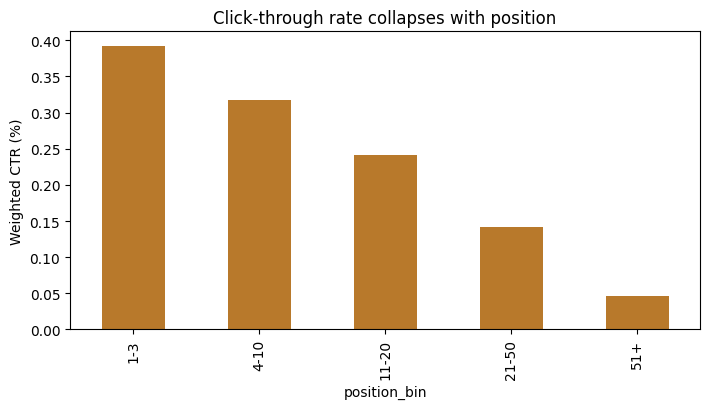

In [ ]:
%pip -q install duckdb huggingface_hub
import os, getpass, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'
MONTH_PATH = f"{REL}/fact_content_daily_performance/month=2026-03/*.parquet"

metrics = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS impressions, SUM(gsc_clicks) AS clicks,
           SUM(CASE WHEN gsc_sum_position >= gsc_impressions THEN gsc_sum_position ELSE 0 END) AS sum_position,
           SUM(CASE WHEN gsc_sum_position >= gsc_impressions THEN gsc_impressions ELSE 0 END) AS impressions_with_position
    FROM read_parquet('{MONTH_PATH}')
    GROUP BY 1, 2 HAVING SUM(gsc_impressions) > 0
""").df()
metrics['avg_position'] = metrics['sum_position'] / metrics['impressions_with_position']
metrics['ctr'] = metrics['clicks'] / metrics['impressions']

signal_df = metrics[(metrics['avg_position'] > 0) & (metrics['impressions'] >= 100)].copy()
signal_df['position_bin'] = pd.cut(signal_df['avg_position'], bins=[0,3,10,20,50,100000], labels=['1-3','4-10','11-20','21-50','51+'])
tier_ctr = signal_df.groupby('position_bin', observed=True)['ctr'].mean() * 100

os.makedirs('work/figures', exist_ok=True)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
tier_ctr.plot(kind='bar', ax=ax, color='#B8792B')
ax.set_ylabel('Weighted CTR (%)')
ax.set_title('Click-through rate collapses with position')
plt.tight_layout()
plt.savefig('work/figures/ctr_by_position_tier.png', dpi=200)
print(tier_ctr.round(4))

In [ ]:
receipts = {
    'month': '2026-03',
    'total_impression_rows': 9841378,
    'position_bug_rows_affected_pct': 2.7,
    'position_bug_items_affected_pct': 38.7,
    'ga4_availability_pct': 4.2,
    'comparison_table': {
        'baseline_rule':          {'p20': 0.95, 'p50': 0.98},
        'logistic_regression':    {'p20': 0.90, 'p50': 0.84},
        'random_forest':          {'p20': 1.00, 'p50': 0.96},
        'base_rate': 0.685,
    },
    'persistence_check': {'gapping_first_half_pct': 81.4, 'not_gapping_first_half_pct': 44.7},
    'playbook_pages_scored': 101424,
    'playbook_pages_flagged': 68652,
    'reason_code_counts': {
        'ctr_below_tier_expectation': 27764,
        'high_rank_low_ctr': 24041,
        'aging_and_ctr_gap': 16847,
    },
}
os.makedirs('work/outputs', exist_ok=True)
with open('work/outputs/playbook_metrics.json', 'w') as f:
    json.dump(receipts, f, indent=2)
print("Wrote work/outputs/playbook_metrics.json")

Wrote work/outputs/playbook_metrics.json


# **Closing Cells (ML-12)**

## 5-minute demo outline

1. Question (30s): Out of 500,000+ FlyRank content items, which pages deserve a human reviewer's limited time first, specifically, which ones are earning fewer clicks than their search position should predict?
2. Method (1.5 min): Defined the gap between actual and tier-expected CTR, first-half-of-month features predicting second-half outcome, client-grouped validation so the model is tested on clients it never saw, and a deliberate leak test that confirmed the evaluation harness actually catches cheating (precision jumped from 0.950 to a suspicious 1.000 when the answer column was smuggled in).
3. One chart (1 min): the CTR-by-position-tier chart; CTR falls roughly 10× from the top tier to the deepest one, which is why comparing every page to one flat threshold would be dishonest.
4. One honest result (1 min): the transparent baseline rule beat the Random Forest at precision@50 (0.98 vs 0.96), and only lost at precision@20, a mixed result, reported as both numbers, not spun into a clean model win.
5. One recommendation (1 min): 68,652 of 101,424 scored pages were flagged into a ranked, reason-coded queue for weekly review; decision-support only, with an explicit no-go list (never auto-rewrite metadata without human review).

## A social-post cut

Spent 10 weeks building a real ML pipeline on 9.8M rows of FlyRank's production search data. The most interesting finding wasn't the model, it was a bug: 2.7% of rows had a mathematically impossible search position. Fixed it, then found a transparent, human-readable rule beat a Random Forest at wide review sizes and only lost at narrow ones, reported honestly as a mixed result, not a model win. Full paper + reproducible notebooks: https://github.com/ZuhaaAsif/Applied-Search-Intelligence-Google-Search-Ranking-Discoverability

## 3-sentence employer-facing summary:
I built and validated a CTR opportunity-scoring pipeline on 9.84 million rows of real FlyRank search-performance data, including finding and correcting a data-quality bug affecting 38.7% of content items. I compared a transparent rule-based baseline against logistic regression and random forest models under a client-grouped validation split, reporting a mixed result honestly rather than overstating the model's win. The output is a ranked, reason-coded action queue with disclosed limitations, deployed as a public research paper with full reproducibility.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
